# Visualization & Storytelling

## Overview

This notebook transforms the project’s lineup, player, and pair-level outputs into visual insights.

The goal is to make the analysis easier to interpret and communicate by highlighting:

- lineup usage vs. performance
- reliable high-impact lineups
- player impact vs. playing time
- player pair synergy patterns

This notebook prepares the project for portfolio presentation, dashboard development, and decision-support storytelling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 200)

## Load processed datasets

We load the curated datasets generated in previous notebooks. These files contain player, lineup, and pair-level performance metrics ready for visualization.

In [2]:
lineup_perf = pd.read_csv("../data/processed/lineup_performance.csv")
reliable_lineups = pd.read_csv("../data/processed/reliable_lineups.csv")
player_impact = pd.read_csv("../data/processed/player_impact.csv")
reliable_player_impact = pd.read_csv("../data/processed/reliable_player_impact.csv")
pair_perf = pd.read_csv("../data/processed/pair_performance.csv")
reliable_pairs = pd.read_csv("../data/processed/reliable_pair_performance.csv")
stable_lineups = pd.read_csv("../data/processed/stable_lineups_modeling.csv")

##  Lineup usage vs performance

This scatter plot compares how much each lineup played against its efficiency. The ideal lineups are located in the upper-right area: high usage and positive performance.

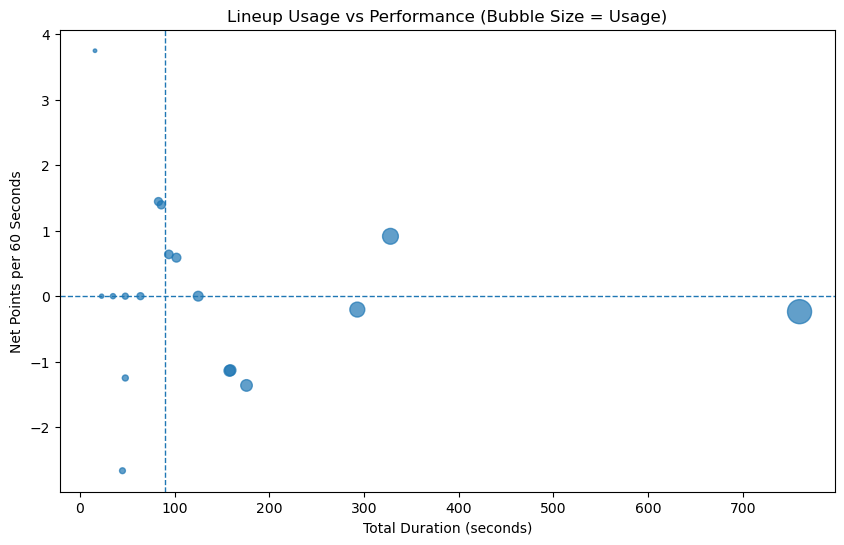

In [8]:
plt.figure(figsize=(10, 6))

sizes = lineup_perf["total_duration"] / lineup_perf["total_duration"].max() * 300

plt.scatter(
    lineup_perf["total_duration"],
    lineup_perf["net_per_60"],
    s=sizes,
    alpha=0.7
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(lineup_perf["total_duration"].median(), linestyle="--", linewidth=1)

plt.xlabel("Total Duration (seconds)")
plt.ylabel("Net Points per 60 Seconds")
plt.title("Lineup Usage vs Performance (Bubble Size = Usage)")

plt.show()

### Interpretation

- Lineups in the upper-right quadrant represent the most valuable combinations (high usage and strong performance)
- Lower-right indicates heavily used but underperforming lineups
- Upper-left suggests potentially underutilized efficient lineups

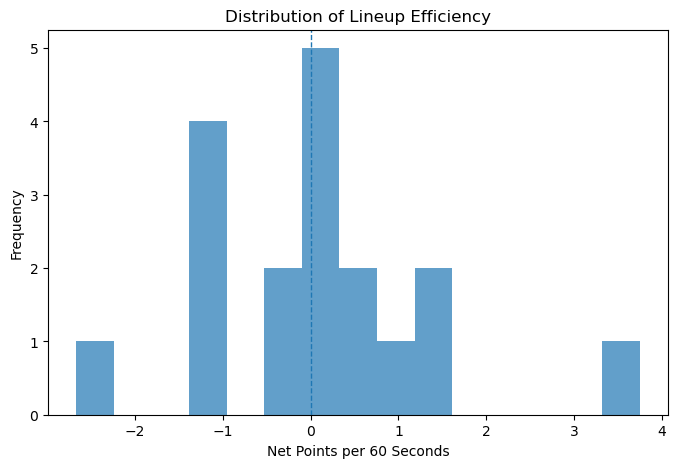

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(lineup_perf["net_per_60"], bins=15, alpha=0.7)

plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("Net Points per 60 Seconds")
plt.ylabel("Frequency")
plt.title("Distribution of Lineup Efficiency")

plt.show()

### Interpretation

The distribution is centered around zero, indicating a relatively balanced game with no extreme dominance from any single lineup.

Most lineups cluster near neutral performance, while a few outliers reflect short-duration stints or particularly effective segments.

##  Top reliable lineups

We visualize the highest-performing lineups after filtering for playing time. This helps avoid overemphasizing very short stints.

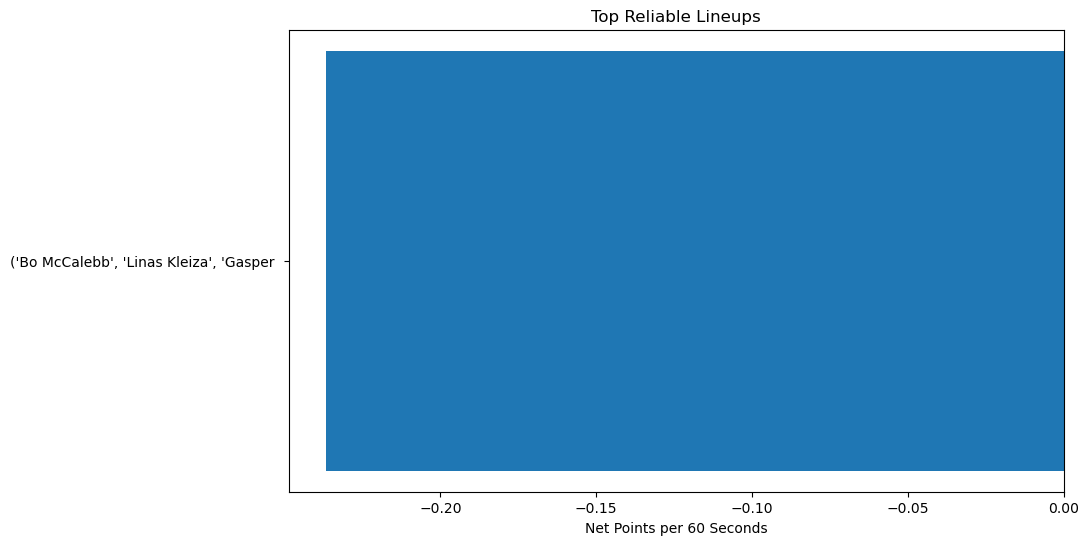

In [9]:
top_lineups = reliable_lineups.sort_values(
    "net_per_60", ascending=False
).head(10).copy()

top_lineups["lineup_short"] = top_lineups["home_lineup_names"].apply(lambda x: str(x)[:40])

plt.figure(figsize=(10, 6))

plt.barh(
    top_lineups["lineup_short"],
    top_lineups["net_per_60"]
)

plt.xlabel("Net Points per 60 Seconds")
plt.title("Top Reliable Lineups")

plt.gca().invert_yaxis()
plt.show()

## Player impact vs playing time

This plot compares player impact with total playing time. It helps distinguish high-impact players with meaningful minutes from short-sample outliers.

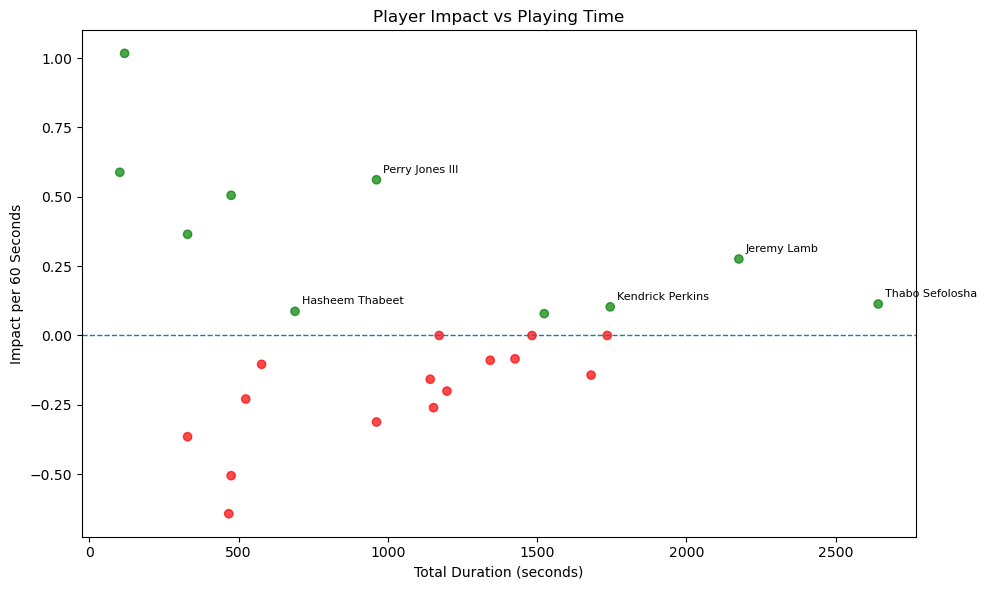

In [16]:
plt.figure(figsize=(10, 6))

colors = np.where(player_impact["impact_per_60_sec"] > 0, "green", "red")

plt.scatter(
    player_impact["total_duration"],
    player_impact["impact_per_60_sec"],
    c=colors,
    alpha=0.7
)

plt.axhline(0, linestyle="--", linewidth=1)

# Label only reliable top players to avoid messy/extreme annotations
top_players = (
    reliable_player_impact
    .sort_values("impact_per_60_sec", ascending=False)
    .head(5)
)

for _, row in top_players.iterrows():
    plt.annotate(
        row["player_name"],
        xy=(row["total_duration"], row["impact_per_60_sec"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Total Duration (seconds)")
plt.ylabel("Impact per 60 Seconds")
plt.title("Player Impact vs Playing Time")
plt.tight_layout()
plt.show()

##  Top reliable player impacts

We focus on players who meet the minimum playing-time threshold to reduce small-sample noise.

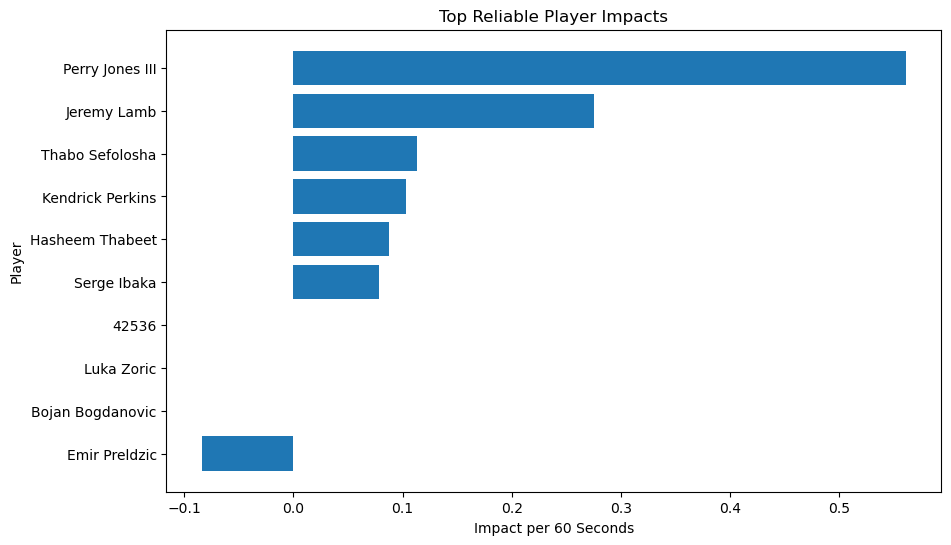

In [6]:
top_players = reliable_player_impact.sort_values(
    "impact_per_60_sec", ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_players["player_name"],
    top_players["impact_per_60_sec"]
)

plt.xlabel("Impact per 60 Seconds")
plt.ylabel("Player")
plt.title("Top Reliable Player Impacts")
plt.gca().invert_yaxis()
plt.show()

## Player pair synergy

Pair synergy identifies player combinations that performed well together. We visualize the strongest reliable pairs by time-normalized impact.

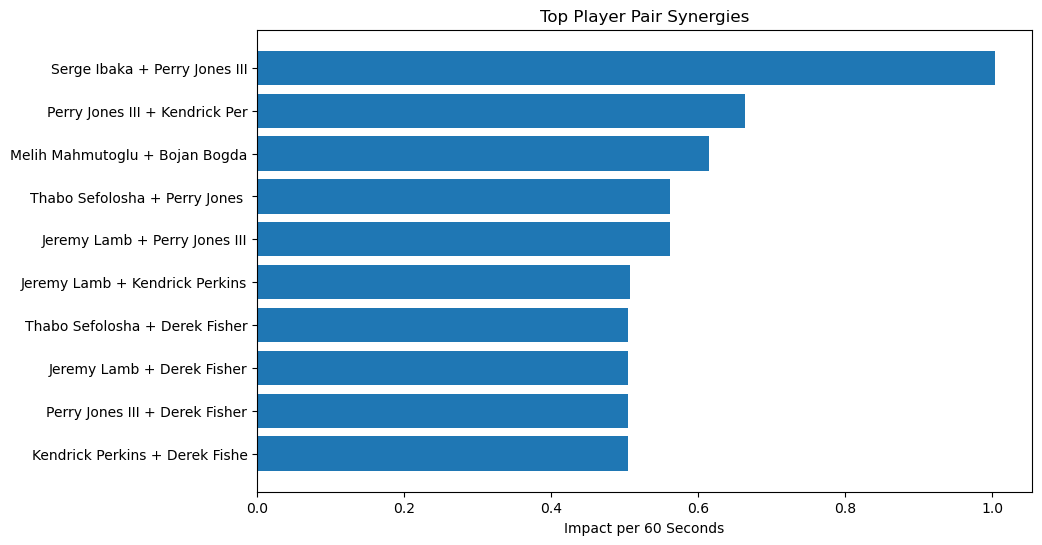

In [11]:
top_pairs = reliable_pairs.sort_values(
    ["impact_per_60", "total_duration"],
    ascending=[False, False]
).head(10).copy()

top_pairs["pair_name"] = (
    top_pairs["player_1_name"].astype(str) + " + " + top_pairs["player_2_name"].astype(str)
)

top_pairs["pair_short"] = top_pairs["pair_name"].apply(lambda x: x[:30])

plt.figure(figsize=(10, 6))

plt.barh(
    top_pairs["pair_short"],
    top_pairs["impact_per_60"]
)

plt.xlabel("Impact per 60 Seconds")
plt.title("Top Player Pair Synergies")

plt.gca().invert_yaxis()
plt.show()

## Key insights

The visual analysis highlights several important patterns:

- Lineup performance varies meaningfully across different player combinations.
- Filtering by playing time helps reduce the influence of short-sample outliers.
- Player impact is more interpretable when evaluated alongside total duration.
- Pair synergy analysis reveals which player combinations contributed positively within this game context.

Overall, these visuals make the project easier to communicate and prepare the analysis for dashboard development.

## Final takeaway

Visualizing lineup and player performance reveals that efficiency must always be interpreted alongside playing time.

High-impact results from short durations can be misleading, while consistently used lineups and players provide more reliable signals.

These visualizations translate the analytical pipeline into intuitive insights, making the results accessible for decision-making and future modeling.

## Next step

The next stage is to move from static analysis into a user-facing dashboard.

The dashboard will allow users to interactively explore:

- player impact
- lineup performance
- usage vs. efficiency
- pair synergy
- recommended high-value lineups